In [3]:
# データを読み込んで形を確認
import pandas as pd

print(pd.read_excel(r"C:\Users\sryoh\Documents\Python_MSSE_analysis\Ex1\89SEDEx1.xls", sheet_name=None))

WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
{'Sheet1':     Time[sec.]     Interval   Interval.1   Interval.2      Interval.3  \
0   Time[sec.]  Nｺ Episodes  Nｺ Episodes  Nｺ Episodes  Time in [sec.]   
1   Time[sec.]       Freez.          Low         High          Freez.   
2           30            3            3            0            24.8   
3           60            4            4            0           29.22   
4           90            0            0            0              30   
5          120            1            1            0           29.98   
6          150            0            0            0              30   
7          180            2            2            0           28.88   
8          210            0            0            0              30   
9          240            0            0            0              30   
10         270            2            2            0           29.92   
11         300            1            1

In [ ]:
# RのコードをPythonに変換 
import pandas as pd


def read_per3_bin(file_path: str, name: str) -> pd.DataFrame: # 3分毎のbinごとにデータを読み込む
    df = pd.read_excel(file_path) # データを読み込む

    bins = [ # 3分毎のbinの範囲とラベル
        (3, 8, "3"),
        (9, 14, "6"),
        (15, 20, "9"),
        (21, 26, "12"),
        (27, 32, "15"),
    ]

    frames = [] # 結果を格納するリスト
    for start, end, time_label in bins: # 3分毎のbinごとにデータを処理
        tmp = (
            df.iloc[:, 4]           # 5列目（0-indexed）
            .iloc[start - 1 : end]  # 行 3:8, 9:14, ...
            .astype(float)          # 数値に変換
            .mul(100 / 30 )         # 30秒ごとのデータを3分ごとの平均に変換
        )

        frames.append( # 結果をリストに追加
            pd.DataFrame({  # データフレームを作成
                "Freezing": [tmp.mean()], # 平均値を計算
                "Time": [time_label], # ラベルを追加
                "No": [name], # 名前を追加
            })
        )

    return pd.concat(frames, ignore_index=True)

# 例:
tmp = read_per3_bin("path/to/file.xls", "animal_name")

In [ ]:
# 3分毎の折れ線グラフ用のFear Extinctionデータの読み込み

from pathlib import Path  # noqa: F811

import numpy as np  # noqa: F811
import pandas as pd

# 自動でエクセルファイルを読み込む

folder_Ex1 = r"C:\Users\sryoh\Documents\Python_MSSE_analysis\Ex1"  # フォルダのパスを指定
folder_Ex2 = r"C:\Users\sryoh\Documents\Python_MSSE_analysis\Ex2"  # フォルダのパスを指定

files_Ex1 = sorted(Path(folder_Ex1).glob("*.xls")) # フォルダ内の .xls ファイルを取得してソート
files_Ex2 = sorted(Path(folder_Ex2).glob("*.xls")) # フォルダ内の .xls ファイルを取得してソート

if not files_Ex1 and not files_Ex2:
    print("指定されたフォルダに .xls ファイルはありません")
else:
    dfs = [] # 空のリストを作成して、各ファイルのデータフレームを格納
    for file in files_Ex1 + files_Ex2: # ファイルごとにループ
        df = (
        pd.read_excel(file) 
        .iloc[2:8, [4]]  # 2行目から7行目まで、4列目を抽出
        .assign(Freezing = lambda df: df['Interval.3'] / 60 * 100 ) # Freezing Time (%) を計算し列に追加
        [['Freezing']] # Freezing列のみを残す
        .assign(
        Time  = lambda df: list(range(1, len(df) + 1)), # Time列に1から行数までの連番を追加
        No = lambda df: Path(file).stem,  # No列にpathからファイル名を抽出して追加
        Group = lambda df: np.select( # Group列に条件に応じた値を追加
            condlist=[ # 条件のリスト：No列に各文字列が含まれているか
                df['No'].str.contains('SED'),
                df['No'].str.contains('LIE'),
                df['No'].str.contains('MOE')
            ],
            choicelist=['SED', 'LIE', 'MOE'], # 条件にマッチしたときに入れる値のリスト
            default='Other' # どれにも当てはまらない場合のデフォルト値
            )
        )
     )
        dfs.append(df) # データフレームをリストに追加

    dataFC = pd.concat(dfs, ignore_index=True) # リスト内のデータフレームを縦に結合して1つのデータフレームにする
    print(f"{len(files_Ex1 + files_Ex2)} 件の .xls ファイルを読み込みました") # 読み込んだファイル数を表示
    print(dataFC) # データフレームの内容を表示

In [3]:
# 上の関数と自動読み込みのコードをハイブリットしたコード

import warnings
from pathlib import Path

import numpy as np
import pandas as pd

# 旧形式 .xls の OLE2 警告を抑制
# warnings.filterwarnings("ignore", message=".*OLE2 inconsistency.*")

def infer_group(name: str) -> str: # ファイル名からグループを推測する関数
    if "SED" in name:
        return "SED"
    elif "LIE" in name:
        return "LIE"
    elif "MOE" in name:
        return "MOE"
    return "Other"

def read_extinction_per3(files):   # 3分ごとのデータを読み込む関数
    rows = [] # 空のリストを作成して、各ファイルのデータを格納

    for file in files:
        # 旧 .xls では pandas で警告が出ることがあるので抑制
        # with warnings.catch_warnings():
            # warnings.filterwarnings("ignore", message=".*OLE2 inconsistency.*")
        df = pd.read_excel(file)

        col5 = pd.to_numeric(df.iloc[:, 4], errors="coerce")  # 5列目（E列）
        bins = [ # 3分毎のbinの範囲とラベル
            (3, 8, "3"),
            (9, 14, "6"),
            (15, 20, "9"),
            (21, 26, "12"),
            (27, 32, "15"),
        ]

        for start, end, time_label in bins: # 3分毎のbinごとにデータを処理
            freezing = (
                col5.iloc[start - 1:end] # 3:8, 9:14, ...
                .astype(float)           # 数値に変換
                .mul(100 / 30)           # 30秒ごとのデータを3分ごとの平均に変換
                .mean()                  # 平均値を計算  
            )
            rows.append({
                "No": Path(file).stem,   # ファイル名を追加
                "Time": time_label,      # ラベルを追加
                "Freezing": freezing,    # 平均値を追加
                "Group": infer_group(Path(file).stem),  # グループを推測して追加
            })

    return pd.DataFrame(rows)

# 既存のフォルダ
folder_Ex1 = r"C:\Users\sryoh\Documents\Python_MSSE_analysis\Ex1"
folder_Ex2 = r"C:\Users\sryoh\Documents\Python_MSSE_analysis\Ex2"

files_Ex1 = sorted(Path(folder_Ex1).glob("*.xls")) # フォルダ内の .xls ファイルを取得してソート
files_Ex2 = sorted(Path(folder_Ex2).glob("*.xls")) # フォルダ内の .xls ファイルを取得してソート

# 3分ごとのデータ
if not files_Ex1 and not files_Ex2:
    print("指定されたフォルダに .xls ファイルはありません")
else:
    dataEx1_per3 = read_extinction_per3(files_Ex1) # Ex1の3分ごとのデータを読み込む
    dataEx2_per3 = read_extinction_per3(files_Ex2) # Ex2の3分ごとのデータを読み込む

    print(f"Ex1: {len(files_Ex1)} 件, Ex2: {len(files_Ex2)} 件") 
    print(dataEx1_per3.head()) 
    print(dataEx2_per3.head())

WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but 

In [21]:
# グラフの描画を関数化
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager
from matplotlib.lines import Line2D

# --- 保存先ディレクトリ ---
SAVE_DIR = Path(r"C:\Users\sryoh\Documents\Python_MSSE_analysis\Results\Plots")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# --- 全体のフォント設定 ---
plt.rcParams.update({ 
    "font.family": ["Times New Roman", "DejaVu Serif", "serif"], # まず Times New Roman を使い、なければ DejaVu Serif、最後に serif を使う
    "axes.unicode_minus": False, # マイナス記号が文字化けしないようにする
})
FONT_PROP = font_manager.FontProperties(family="Times New Roman") # Times New Roman を明示的に指定するための FontProperties を作る


# 軸やタイトルの見た目をまとめて整える補助関数
def _apply_axis_style(
    ax,
    *,
    title,
    xlabel,
    ylabel,
    ylim,
    xticks,
    tick_size=12,
):
    ax.set_ylim(*ylim)
    ax.set_yticks(np.arange(ylim[0], ylim[1] + 1, 20))
    ax.set_xticks(xticks)

    ax.set_title(title, fontsize=14, fontfamily="Times New Roman", pad=10)
    ax.set_xlabel(xlabel, fontsize=12, fontfamily="Times New Roman")
    ax.set_ylabel(ylabel, fontsize=12, fontfamily="Times New Roman")

    ax.tick_params(axis="both", labelsize=tick_size)
    for label in ax.get_xticklabels() + ax.get_yticklabels():  # x軸とy軸の目盛りラベルをすべて取得
        label.set_fontproperties(FONT_PROP)                    # 目盛りラベルにも Times New Roman を適用する

    return ax


 # 凡例に使うマーカーをまとめて作る補助関数
def _make_legend_handles(palette, group_order):
    return [
        Line2D(
            [0], [0],
            linestyle="",
            marker="o",
            markersize=8,
            markerfacecolor=palette[group],
            markeredgecolor="black",
            markeredgewidth=0.5,
            color=palette[group],
            label=group,
        )
        for group in group_order
    ]

 # 3群の折れ線グラフを統一して描画し、保存もできる関数
def plot_save(
    df,
    *,
    title="Extinction",
    group_col="Group",
    time_col="Time",
    value_col="Freezing",
    group_order=("SED", "LIE", "MOE"),
    palette=None,
    xlabel="Time (min)",
    ylabel="Freezing Time (%)",
    ylim=(0, 100),
    xticks=(3, 6, 9, 12, 15),
    figsize=(3, 3),
    save_path=None,
    show_legend=True,
    legend_loc="upper left",
    legend_title=None,
    legend_frameon=False,
    method="seaborn",
):
    if palette is None:
        palette = {
            "SED": "gray",
            "LIE": "skyblue",
            "MOE": "lightgreen",
        }

    df = df.copy() # 元のデータを壊さないようにコピーする
    df[time_col] = pd.to_numeric(df[time_col], errors="coerce")  # Time 列を数値に変換し、変換できないものは NaN にする
    df = df.dropna(subset=[time_col, value_col, group_col])  # 時間、値、群のどれかが欠測の行を削除する

    fig, ax = plt.subplots(figsize=figsize) # グラフの図と軸を作成する

    if method == "seaborn":
        sns.set_theme(style="ticks")
        sns.lineplot(
            data=df,
            x=time_col,
            y=value_col,
            hue=group_col,
            hue_order=list(group_order),
            palette=palette,
            estimator="mean",
            errorbar="se",
            marker="o",
            markersize=8,
            linewidth=1.5,
            err_style="bars",
            err_kws={
                "ecolor": "black",
                "elinewidth": 0.5,
                "capsize": 3,
                "capthick": 0.5,
                "zorder": 1,
            },
            markeredgecolor="black",
            markeredgewidth=0.5,
            ax=ax,
        )
        sns.despine(ax=ax)

    elif method == "matplotlib":
        # 各群ごとに時間別に平均、標準偏差、サンプル数を計算する
        summary = (
            df.groupby([group_col, time_col], as_index=False)[value_col]
            .agg(mean="mean", std="std", n="count")
        )
         # 標準誤差を計算する
        summary["se"] = summary["std"] / np.sqrt(summary["n"])

        for group in group_order:
            tmp = summary[summary[group_col] == group].sort_values(time_col) # その群だけを抽出し、時間順に並べる
            ax.errorbar(
                tmp[time_col],
                tmp["mean"],
                yerr=tmp["se"],
                fmt="o-",
                color=palette.get(group, "black"),
                ecolor="black",
                elinewidth=0.5,
                capsize=3,
                markersize=8,
                linewidth=1.5,
                label=group,
                markeredgecolor="black",
                markeredgewidth=0.5,
            )

        ax.grid(False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_color("black")
        ax.spines["bottom"].set_color("black")
        ax.spines["left"].set_linewidth(1.5)
        ax.spines["bottom"].set_linewidth(1.5)

    else:
        raise ValueError("method must be 'seaborn' or 'matplotlib'")

    _apply_axis_style(
        ax,
        title=title,
        xlabel=xlabel,
        ylabel=ylabel,
        ylim=ylim,
        xticks=xticks,
    )

    if show_legend:
        handles = _make_legend_handles(palette, group_order)
        legend = ax.legend(
            handles=handles,
            loc=legend_loc,
            frameon=legend_frameon,
            title=legend_title,
            borderaxespad=0,
            handletextpad=0.2,
        )
        for text in legend.get_texts():
            text.set_fontproperties(FONT_PROP)
    else:
        legend = ax.get_legend()
        if legend is not None:
            legend.set_visible(False)

    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, ax

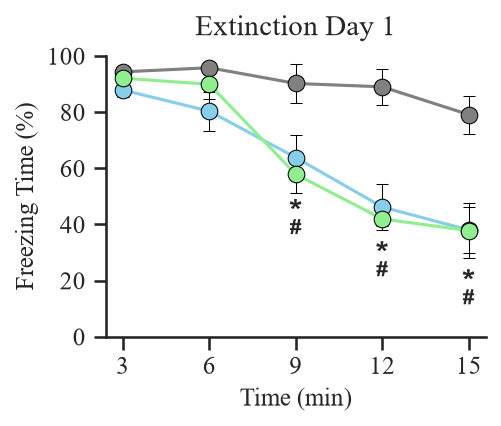

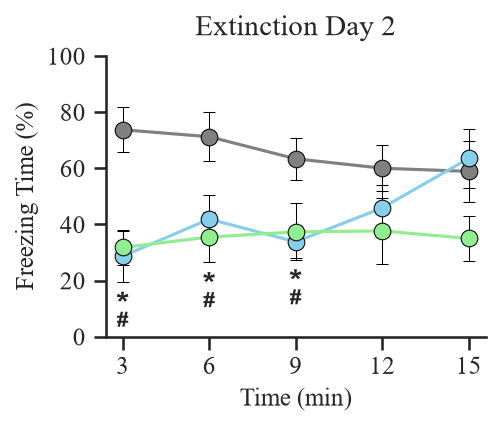

In [22]:
# 関数を使ってグラフを描画 (seaborn)

figEx1, axEx1 = plot_save(
    dataEx1_per3,
    title="Extinction Day 1",
    group_order=["SED", "LIE", "MOE"],
    save_path=r"C:\Users\sryoh\Documents\Python_MSSE_analysis\Results\Plots\Extinction_day1_per3_seaborn.png",
    show_legend=False,
    figsize=(3.5, 3),
    method="seaborn",
)

# 有意マーカーを描画
axEx1.text(9, 38, "*", ha="center", va="bottom", fontsize=16, fontweight="bold")
axEx1.text(12, 23, "*", ha="center", va="bottom", fontsize=16, fontweight="bold")
axEx1.text(15, 13, "*", ha="center", va="bottom", fontsize=16, fontweight="bold") # noqa: F821
axEx1.text(9, 35, "#", ha="center", va="bottom", fontsize=10, fontweight="bold")
axEx1.text(12, 20, "#", ha="center", va="bottom", fontsize=10, fontweight="bold")
axEx1.text(15, 10, "#", ha="center", va="bottom", fontsize=10, fontweight="bold") # noqa: F821

figEx1.tight_layout()

figEx1.savefig(
    r"C:\Users\sryoh\Documents\Python_MSSE_analysis\Results\Plots\Extinction_day1_per3_seaborn_sig.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

figEx2, axEx2 = plot_save(
    dataEx2_per3,
    title="Extinction Day 2",
    group_order=["SED", "LIE", "MOE"],
    save_path=r"C:\Users\sryoh\Documents\Python_MSSE_analysis\Results\Plots\Extinction_day2_per3_seaborn.png",
    show_legend=False,
    figsize=(3.5,3),
    method="seaborn",
)

# 有意マーカーを描画
axEx2.text(3, 5, "*", ha="center", va="bottom", fontsize=16, fontweight="bold")
axEx2.text(6, 12, "*", ha="center", va="bottom", fontsize=16, fontweight="bold")
axEx2.text(9, 13, "*", ha="center", va="bottom", fontsize=16, fontweight="bold") # noqa: F821
axEx2.text(3, 2, "#", ha="center", va="bottom", fontsize=10, fontweight="bold")
axEx2.text(6, 9, "#", ha="center", va="bottom", fontsize=10, fontweight="bold")
axEx2.text(9, 10, "#", ha="center", va="bottom", fontsize=10, fontweight="bold") # noqa: F821

figEx2.tight_layout()

figEx2.savefig(
    r"C:\Users\sryoh\Documents\Python_MSSE_analysis\Results\Plots\Extinction_day2_per3_seaborn_sig.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

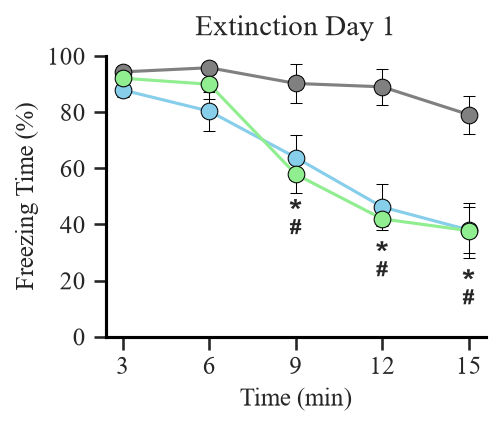

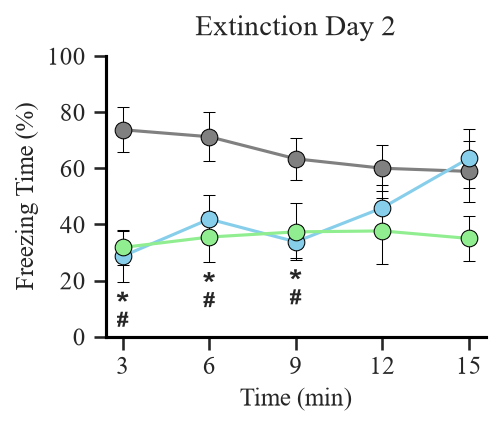

In [23]:
# matplot_lib版でもグラフを描画

figEx1, axEx1 = plot_save(
    dataEx1_per3,
    title="Extinction Day 1",
    group_order=["SED", "LIE", "MOE"],
    save_path=r"C:\Users\sryoh\Documents\Python_MSSE_analysis\Results\Plots\Extinction_day1_per3_matplotlib.png",
    show_legend=False,
    figsize=(3.5, 3),
    method="matplotlib",
)

# 有意マーカーを描画
axEx1.text(9, 38, "*", ha="center", va="bottom", fontsize=16, fontweight="bold")
axEx1.text(12, 23, "*", ha="center", va="bottom", fontsize=16, fontweight="bold")
axEx1.text(15, 13, "*", ha="center", va="bottom", fontsize=16, fontweight="bold") # noqa: F821
axEx1.text(9, 35, "#", ha="center", va="bottom", fontsize=10, fontweight="bold")
axEx1.text(12, 20, "#", ha="center", va="bottom", fontsize=10, fontweight="bold")
axEx1.text(15, 10, "#", ha="center", va="bottom", fontsize=10, fontweight="bold") # noqa: F821

figEx1.tight_layout()

figEx1.savefig(
    r"C:\Users\sryoh\Documents\Python_MSSE_analysis\Results\Plots\Extinction_day1_per3_matplotlib_sig.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

figEx2, axEx2 = plot_save(
    dataEx2_per3,
    title="Extinction Day 2",
    group_order=["SED", "LIE", "MOE"],
    save_path=r"C:\Users\sryoh\Documents\Python_MSSE_analysis\Results\Plots\Extinction_day2_per3_matplotlib.png",
    show_legend=False,
    figsize=(3.5,3),
    method="matplotlib",
)

# 有意マーカーを描画
axEx2.text(3, 5, "*", ha="center", va="bottom", fontsize=16, fontweight="bold")
axEx2.text(6, 12, "*", ha="center", va="bottom", fontsize=16, fontweight="bold")
axEx2.text(9, 13, "*", ha="center", va="bottom", fontsize=16, fontweight="bold") # noqa: F821
axEx2.text(3, 2, "#", ha="center", va="bottom", fontsize=10, fontweight="bold")
axEx2.text(6, 9, "#", ha="center", va="bottom", fontsize=10, fontweight="bold")
axEx2.text(9, 10, "#", ha="center", va="bottom", fontsize=10, fontweight="bold") # noqa: F821

figEx2.tight_layout()

figEx2.savefig(
    r"C:\Users\sryoh\Documents\Python_MSSE_analysis\Results\Plots\Extinction_day2_per3_matplotlib_sig.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but 

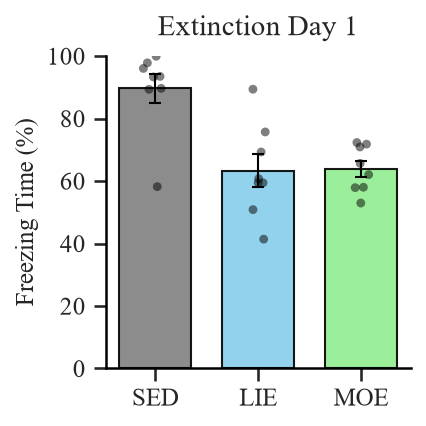

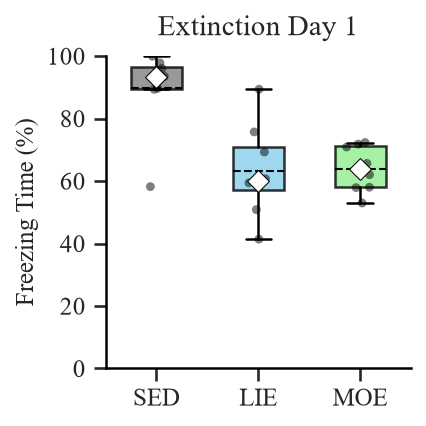

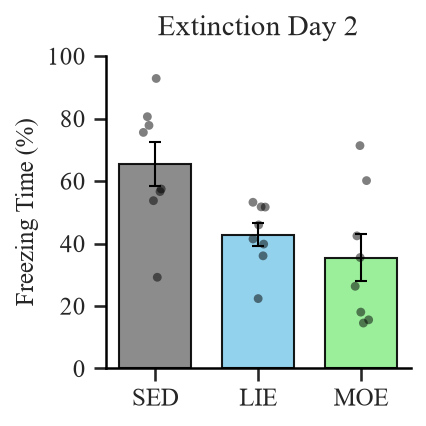

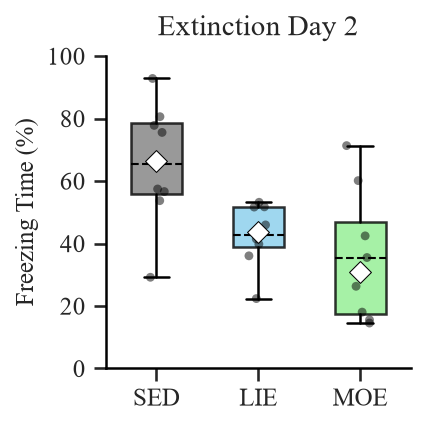

In [31]:
# これまでを掛け合わせ、データの読み込みからさらに棒グラフ、箱ひげ図まで出力する関数
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

# -----------------------------
# フォント設定
# -----------------------------
plt.rcParams.update({
    "font.family": ["Times New Roman", "DejaVu Serif", "serif"],
    "axes.unicode_minus": False,
})
FONT_PROP = font_manager.FontProperties(family="Times New Roman")


# -----------------------------
# 既存の関数: 15分全体の集計
# -----------------------------
def infer_group(name: str) -> str:  # noqa: F811
    if "SED" in name:
        return "SED"
    elif "LIE" in name:
        return "LIE"
    elif "MOE" in name:
        return "MOE"
    return "Other"


def read_extinction_per15(files):
    rows = []

    for file in files:
        df = pd.read_excel(file)
        col5 = pd.to_numeric(df.iloc[:, 4], errors="coerce")

        bins = [
            (3, 8, "3"),
            (9, 14, "6"),
            (15, 20, "9"),
            (21, 26, "12"),
            (27, 32, "15"),
        ]

        values = []
        for start, end, _ in bins:
            freezing = (
                col5.iloc[start - 1:end]
                .astype(float)
                .mul(100 / 30)
                .mean()
            )
            values.append(freezing)

        overall_freezing = np.mean(values) if values else np.nan

        rows.append({
            "No": Path(file).stem,
            "Freezing": overall_freezing,
            "Group": infer_group(Path(file).stem),
        })

    return pd.DataFrame(rows)


# -----------------------------
# 棒グラフ（平均 + エラーバー + Jitter）
# -----------------------------
def plot_group_bar_jitter(
    df,
    *,
    group_col="Group",
    value_col="Freezing",
    group_order=("SED", "LIE", "MOE"),
    palette=None,
    title="Freezing Time (%)",
    xlabel="",
    ylabel="Freezing Time (%)",
    ylim=(0, 100),
    figsize=(3, 3),
    save_path=None,
):
    if palette is None:
        palette = {
            "SED": "gray",
            "LIE": "skyblue",
            "MOE": "lightgreen",
        }

    df = df.copy().dropna(subset=[group_col, value_col])
    groups = [g for g in group_order if g in df[group_col].unique()]

    summary = (
        df.groupby(group_col, as_index=False)[value_col]
        .agg(mean="mean", std="std", n="count")
    )
    summary["se"] = summary["std"] / np.sqrt(summary["n"])

    summary[group_col] = pd.Categorical(summary[group_col], categories=groups, ordered=True)
    summary = summary.sort_values(group_col)

    fig, ax = plt.subplots(figsize=figsize)

    x_pos = np.arange(len(groups))
    bar_means = summary["mean"].to_numpy()
    bar_se = summary["se"].to_numpy()

    ax.bar(
        x_pos,
        bar_means,
        width=0.7,
        color=[palette[g] for g in groups],
        edgecolor="black",
        linewidth=1.0,
        alpha=0.9,
        yerr=bar_se,
        capsize=3,
        error_kw={
            "ecolor": "black",
            "elinewidth": 1.0,
            "capthick": 1.0,
        },
        zorder=2,
    )

    # 個体ごとの Jitter
    rng = np.random.default_rng(42)
    for i, group in enumerate(groups):
        vals = df.loc[df[group_col] == group, value_col].to_numpy()
        jitter_x = rng.normal(loc=i, scale=0.06, size=len(vals))
        ax.scatter(
            jitter_x,
            vals,
            s=18,
            color="black",
            alpha=0.5,
            edgecolors="none",
            zorder=3,
        )

    ax.set_xticks(x_pos)
    ax.set_xticklabels(groups, fontfamily="Times New Roman")
    ax.set_ylabel(ylabel, fontsize=12, fontfamily="Times New Roman")
    ax.set_xlabel(xlabel, fontsize=12, fontfamily="Times New Roman")
    ax.set_xlabel("")  # x軸タイトルを空にする
    ax.xaxis.label.set_visible(False)

    ax.set_title(title, fontsize=14, fontfamily="Times New Roman", pad=10)
    ax.set_ylim(*ylim)
    ax.set_yticks(np.arange(ylim[0], ylim[1] + 1, 20))

    ax.tick_params(axis="both", labelsize=11)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontproperties(FONT_PROP)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("black")
    ax.spines["bottom"].set_color("black")
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)

    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, ax


# -----------------------------
# 箱ひげ図（Jitter + 平均値 + 中央値）
# -----------------------------
def plot_group_boxplot(
    df,
    *,
    group_col="Group",
    value_col="Freezing",
    group_order=("SED", "LIE", "MOE"),
    palette=None,
    title="Freezing Time (%)",
    xlabel="",
    ylabel="Freezing Time (%)",
    ylim=(0, 100),
    figsize=(3, 3),
    save_path=None,
):
    if palette is None:
        palette = {
            "SED": "gray",
            "LIE": "skyblue",
            "MOE": "lightgreen",
        }

    df = df.copy().dropna(subset=[group_col, value_col])
    groups = [g for g in group_order if g in df[group_col].unique()]
    data = [df.loc[df[group_col] == g, value_col].to_numpy() for g in groups]

    fig, ax = plt.subplots(figsize=figsize)

    bp = ax.boxplot(
        data,
        patch_artist=True,
        widths=0.5,
        showfliers=False,
        showmeans=True,
        meanline=True,
        meanprops={"color": "black", "linewidth": 1},
        medianprops={"color": "none", "linewidth": 0},
        boxprops={"edgecolor": "black", "linewidth": 1.2},
        whiskerprops={"color": "black", "linewidth": 1.2},
        capprops={"color": "black", "linewidth": 1.2},
    )

    # 箱の塗りつぶし
    for patch, group in zip(bp["boxes"], groups):
        patch.set_facecolor(palette[group])
        patch.set_alpha(0.8)
        patch.set_edgecolor("black")

    # 中央値: ひし形（白抜き）
    for i, group in enumerate(groups, start=1):
        median_value = np.median(df.loc[df[group_col] == group, value_col].to_numpy())
        ax.scatter(
            i,
            median_value,
            marker="D",
            s=55,
            facecolor="white",
            edgecolor="black",
            linewidth=.5,
            zorder=5,
        )

    # Jitter
    rng = np.random.default_rng(123)
    for i, group in enumerate(groups, start=1):
        vals = df.loc[df[group_col] == group, value_col].to_numpy()
        jitter_x = rng.normal(loc=i, scale=0.06, size=len(vals))
        ax.scatter(
            jitter_x,
            vals,
            s=18,
            color="black",
            alpha=0.5,
            edgecolors="none",
            zorder=3,
        )

    ax.set_xticks(range(1, len(groups) + 1))
    ax.set_xticklabels(groups, fontfamily="Times New Roman")
    ax.set_ylabel(ylabel, fontsize=12, fontfamily="Times New Roman")
    ax.set_xlabel(xlabel, fontsize=12, fontfamily="Times New Roman")
    ax.set_xlabel("")  # x軸タイトルを空にする
    ax.xaxis.label.set_visible(False)

    ax.set_title(title, fontsize=14, fontfamily="Times New Roman", pad=10)
    ax.set_ylim(*ylim)
    ax.set_yticks(np.arange(ylim[0], ylim[1] + 1, 20))

    ax.tick_params(axis="both", labelsize=11)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontproperties(FONT_PROP)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("black")
    ax.spines["bottom"].set_color("black")
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)

    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, ax


# -----------------------------
# 使い方: Ex1 / Ex2 をまとめて作成
# -----------------------------
dataEx1_per15 = read_extinction_per15(files_Ex1)
dataEx2_per15 = read_extinction_per15(files_Ex2)

for label, (title, df) in {
    "Ex1": ("Extinction Day 1", dataEx1_per15),
    "Ex2": ("Extinction Day 2", dataEx2_per15),
}.items():
    globals()[f"fig_{label}_bar"], globals()[f"ax_{label}_bar"] = plot_group_bar_jitter(
        df,
        title=title,
        ylabel="Freezing Time (%)",
        ylim=(0, 100),
        save_path=f"C:/Users/sryoh/Documents/Python_MSSE_analysis/Results/Plots/{label}_bar_jitter.png",
    )

    globals()[f"fig_{label}_box"], globals()[f"ax_{label}_box"] = plot_group_boxplot(
        df,
        title=title,
        ylabel="Freezing Time (%)",
        ylim=(0, 100),
        save_path=f"C:/Users/sryoh/Documents/Python_MSSE_analysis/Results/Plots/{label}_boxplot_mean.png",
    )